> The sole purpose of this notebook to prove that physics model works as a standalone baseline before XGBoost touches anything.

### Import Libraries

In [10]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from pvlib.location import Location
from sklearn.metrics import r2_score
from src.physics.clear_sky import compute_physics_pred

### Load the data

In [7]:
df_solar = pd.read_parquet("../data/raw/solar_2022_2024.parquet")
df_weather = pd.read_parquet("../data/raw/weather_2022_2024.parquet")
df = pd.merge(df_solar, df_weather, on="time").set_index("time")
df.head()

,solar_mw,hour,shortwave_radiation,cloud_cover,temperature_2m,wind_speed_10m
time,,,,,,
2022-01-01 00:00:00+00:00,2.0,0,0.0,100,10.5,16.8
2022-01-01 01:00:00+00:00,2.0,1,0.0,100,10.6,17.2
2022-01-01 02:00:00+00:00,2.0,2,0.0,100,10.4,17.8
2022-01-01 03:00:00+00:00,2.0,3,0.0,96,10.5,19.5
2022-01-01 04:00:00+00:00,2.0,4,0.0,100,9.7,15.9


### Compute physics prediction

In [9]:
df["physics_pred"] = compute_physics_pred(df.index)
df["residual"] = df["solar_mw"] - df["physics_pred"]
df["residual"].head()

The First 10 rows of the series `physics_pred` is: 
time
2022-01-01 00:00:00+00:00    0.0
2022-01-01 01:00:00+00:00    0.0
2022-01-01 02:00:00+00:00    0.0
2022-01-01 03:00:00+00:00    0.0
2022-01-01 04:00:00+00:00    0.0
Name: physics_pred, dtype: float64


time
2022-01-01 00:00:00+00:00    2.0
2022-01-01 01:00:00+00:00    2.0
2022-01-01 02:00:00+00:00    2.0
2022-01-01 03:00:00+00:00    2.0
2022-01-01 04:00:00+00:00    2.0
Name: residual, dtype: float64

### Evaluate physics baseline (daylight hours only)
#### $R^2$
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
- $SS_{res}$: Residual Sum of Squares (how much the model missed)
- $SS_{tot}$: the Total Sum of Squares (how much the actual data varies from its own mean). This represents the "baseline" variance of the solar output

In [11]:
# Filter for daylight hours (where the sun is actually up)
df_day = df[df["solar_mw"] > 50].copy()
# calculate three metrices (mean, RMSE, and R^2 ((the Coefficient of Determination)))
df_day_mean = (df_day["solar_mw"] - df_day["physics_pred"]).abs().mean()
df_day_rmse = ((df_day["solar_mw"] - df_day["physics_pred"])**2).mean()**0.5

ss_res = ((df_day["solar_mw"] - df_day["physics_pred"])**2).sum()
ss_tot = ((df_day["solar_mw"] - df_day["solar_mw"].mean())**2).sum()
df_day_r2 = 1 - (ss_res / ss_tot)

print(f"Mean Score: {df_day_mean:.4f}")
print(f"RMSE Score: {df_day_rmse:.4f}")
print(f"R² Score: {df_day_r2:.4f}")

Mean Score: 3856.2839
RMSE Score: 5179.3135
R² Score: 0.7804


### Plot this residual distribution

<Axes: >

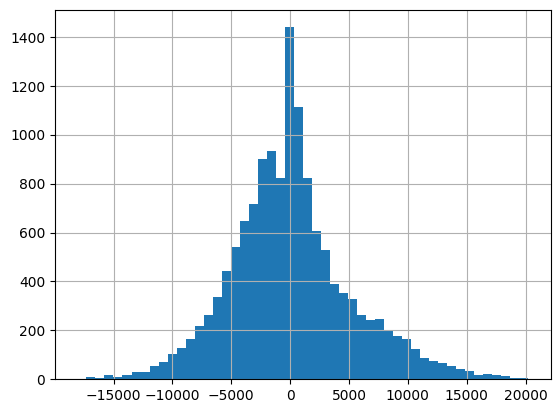

In [12]:
df_day["residual"].hist(bins=50)

### Plot residual vs cloud cover scatter

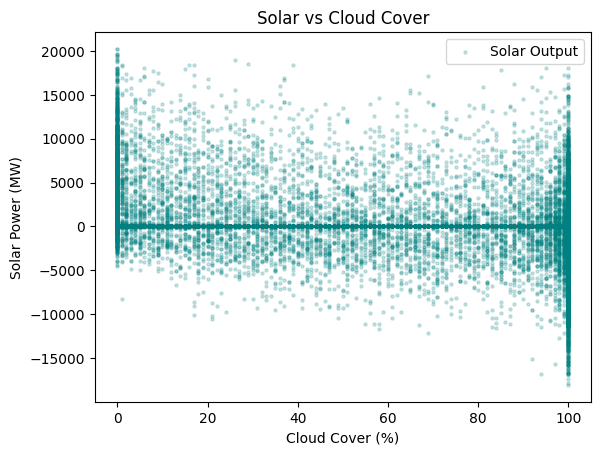

In [13]:
fig, ax = plt.subplots()
ax.scatter(df["cloud_cover"], df["residual"], color='teal', alpha=0.2, s=5)
ax.set_title('Solar vs Cloud Cover')
ax.set_xlabel('Cloud Cover (%)')
ax.set_ylabel('Solar Power (MW)')
ax.legend(['Solar Output'])

plt.show()

### Plot monthly mean residual

<Axes: xlabel='time'>

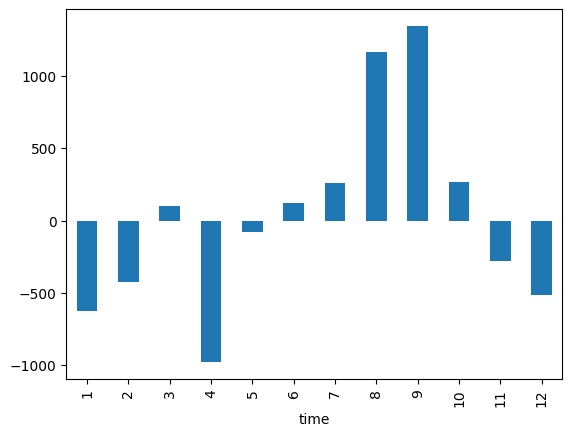

In [14]:
df.groupby(df.index.month)["residual"].mean().plot(kind="bar")

## Key Findings (Physics Baseline)

| Metric | Value | Meaning |
|---|---|---|
| MAE | 3,856 MW | Average error during daylight hours |
| RMSE | 5,179 MW | Penalises large errors (cloudy days) more heavily |
| R² | 0.78 | Physics alone explains 78% of daylight variance |

**What this actually means:**
- The sun geometry model is a strong baseline: free, interpretable, zero training data needed
- The 22% unexplained variance is the XGBoost target: cloud cover, aerosols, curtailments, panel degradation
- Residual distribution is roughly bell-shaped centred below 0: physics slightly overestimates on average (clouds are the norm, not the exception, in Germany)
- Monthly residual plot shows the largest errors in winter: low sun angle makes the Ineichen-Perez scaling factor less accurate

**Next step:** XGBoost residual learner (Phase 3). Needs to be trained on `[cloud_cover, shortwave_radiation, temperature_2m, wind_speed_10m, hour, month]` to predict `residual`.
